# Iris Classification using OvR (One vs Rest) Multi-class classifier 

## Coded By : Himel Sarder
## info.himelcse@gmail.com
## Linkedin : https://www.linkedin.com/in/himel-sarder/

In [158]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Load Main Dataset

In [159]:
df = pd.read_csv("/kaggle/input/irisdataset/Iris.csv")

In [160]:
df.head()

,petal_length,petal_width,sepal_length,sepal_width,label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Count of Label

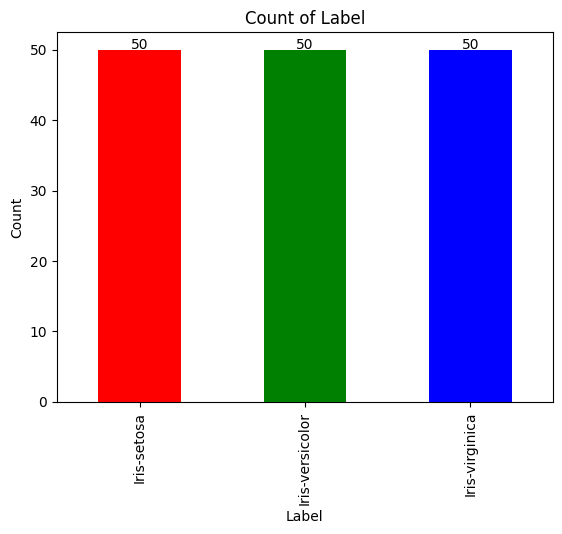

In [161]:
import matplotlib.pyplot as plt

# Bar plot
ax = df['label'].value_counts().plot(kind='bar', color=['red', 'green', 'blue'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Label')

# Add count labels on top of bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,  
        p.get_height() + 0.1,       
        int(p.get_height()),  
        ha='center'
    )

plt.show()

# One Hot Encoding

In [163]:
df = pd.get_dummies(df, columns=['label'], dtype=int)
df.head()

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-setosa,label_Iris-versicolor,label_Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


# Divide the Main dataset into sub-datasets with separate class

In [164]:
df1 = df.iloc[:, 0:5]
df1.head()

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-setosa
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [165]:
df2 = pd.concat([df.iloc[:, 0:4], df.iloc[:, [5]]], axis=1)
df2.sample(5)

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-versicolor
129,7.2,3.0,5.8,1.6,0
121,5.6,2.8,4.9,2.0,0
95,5.7,3.0,4.2,1.2,1
132,6.4,2.8,5.6,2.2,0
74,6.4,2.9,4.3,1.3,1


In [166]:
df3 = pd.concat([df.iloc[:, 0:4], df.iloc[:, [-1]]], axis=1)
df3.sample(5)

,petal_length,petal_width,sepal_length,sepal_width,label_Iris-virginica
36,5.5,3.5,1.3,0.2,0
61,5.9,3.0,4.2,1.5,0
46,5.1,3.8,1.6,0.2,0
66,5.6,3.0,4.5,1.5,0
1,4.9,3.0,1.4,0.2,0


In [167]:
models = []

In [168]:
X_train = df.iloc[:, 0:4]
X_train.head()

,petal_length,petal_width,sepal_length,sepal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [169]:
y_train_model1 = df1.iloc[:, -1]
y_train_model1.head()

0    1
1    1
2    1
3    1
4    1
Name: label_Iris-setosa, dtype: int64

In [170]:
y_train_model2 = df2.iloc[:, -1]
y_train_model2.head()

0    0
1    0
2    0
3    0
4    0
Name: label_Iris-versicolor, dtype: int64

In [171]:
y_train_model3 = df3.iloc[:, -1]
y_train_model3.head()

0    0
1    0
2    0
3    0
4    0
Name: label_Iris-virginica, dtype: int64

# Train Logistic Regression to Dataset 1

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [173]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_train, y_train_model1.values, test_size=0.3, random_state=42)

In [174]:
model1 = LogisticRegression(max_iter=500)
model1.fit(X_train1, y_train1)
models.append(model1)

In [175]:
models

[LogisticRegression(max_iter=500)]

# Train Logistic Regression to Dataset 2

In [176]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train, y_train_model2.values, test_size=0.3, random_state=42)

In [177]:
model2 = LogisticRegression(max_iter=500)
model2.fit(X_train2, y_train2)
models.append(model2)

In [178]:
models

[LogisticRegression(max_iter=500), LogisticRegression(max_iter=500)]

# Train Logistic Regression to Dataset 3

In [179]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_train, y_train_model3.values, test_size=0.3, random_state=42)

In [180]:
model3 = LogisticRegression(max_iter=500)
model3.fit(X_train3, y_train3)
models.append(model3)

In [181]:
models

[LogisticRegression(max_iter=500),
 LogisticRegression(max_iter=500),
 LogisticRegression(max_iter=500)]

# Predict probabilities for each class

In [182]:
probas = np.column_stack([model.predict_proba(X_test)[:, 1] for model in models])

In [183]:
probas

array([[4.84313598e-03, 5.31020136e-01, 2.13486047e-01],
       [9.51268754e-01, 5.82256403e-02, 1.30370013e-05],
       [6.69568369e-06, 5.93551351e-01, 9.98133461e-01],
       [6.44942052e-03, 3.86003073e-01, 2.23305055e-01],
       [2.42938077e-03, 4.58518092e-01, 2.99868798e-01],
       [9.57195574e-01, 1.14885128e-01, 1.18554812e-05],
       [6.04962072e-02, 3.36102581e-01, 1.98550935e-02],
       [6.96923872e-04, 1.78408777e-01, 8.29504135e-01],
       [3.31697051e-03, 7.36316556e-01, 2.60037475e-01],
       [2.78528377e-02, 4.92948044e-01, 3.59226058e-02],
       [1.17468345e-03, 2.01834453e-01, 7.44247916e-01],
       [9.71082626e-01, 3.09572728e-01, 6.94404334e-06],
       [9.77259856e-01, 9.92207395e-02, 4.41125852e-06],
       [9.65737853e-01, 2.71077460e-01, 8.46256489e-06],
       [9.74856762e-01, 5.96310054e-02, 9.15472514e-06],
       [4.71102414e-03, 1.98844555e-01, 3.19466446e-01],
       [1.83113210e-04, 3.23192728e-01, 9.67179201e-01],
       [2.80681155e-02, 6.34048

# Choose the class with the highest probability

In [184]:
# True labels combined
y_test_combined = np.column_stack([y_test1, y_test2, y_test3])

In [185]:
y_pred_indices = np.argmax(probas, axis=1)
y_true_indices = np.argmax(y_test_combined, axis=1)

In [186]:
y_pred_indices

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2, 1, 0,
       0])

In [187]:
y_true_indices

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

# Accuracy

In [188]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true_indices, y_pred_indices)
print("OvR Logistic Regression Accuracy:", accuracy)

OvR Logistic Regression Accuracy: 0.9555555555555556


# Sample Test

In [189]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])

In [190]:
# Predict probabilities for each class using trained models
probas_sample = np.array([model.predict_proba(sample)[:, 1][0] for model in models])

In [191]:
# Choose the class with the highest probability
class_names = ['label_Iris-setosa','label_Iris-versicolor','label_Iris-virginica']
predicted_class = class_names[np.argmax(probas_sample)]

In [192]:
print("Predicted probabilities:", probas_sample)
print("Predicted class:", predicted_class)

Predicted probabilities: [9.76195089e-01 1.12962812e-01 6.44815802e-06]
Predicted class: label_Iris-setosa
